# 08 — Mapping scale-up: simulating a region of the Moon (naive vs. symmetry, across backends)

The retrieval notebooks solve **one borehole** at a time. Here we ask the
scaling question: to make a **map**, we solve many surface pixels. This
notebook

1. times **one pixel** with the production (Numba) solver,
2. compares the **naive process** — solve every pixel — across the three solver
   backends (pure Python, Numba, C++), and extrapolates to the whole Moon,
3. runs the **smart process** — with global values the cycle depends only on
   latitude, so solve each latitude once and assemble the map,
4. drapes the map on the **real lunar surface** (craters + relief),
5. adds the **polar regions**.

Everything uses **global values**; nothing here is a per-site result.

In [1]:
import sys, time, json, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.image import imread
from matplotlib.colors import LightSource, Normalize

here = pathlib.Path.cwd()
CODE = next(p for p in [here, *here.parents] if (p / 'src' / 'lunar').exists())
sys.path.insert(0, str(CODE / 'src'))

from lunar.config import HAYNE, GRID, DT_STEP, SITES
from lunar.constants import Q_B_EQUATORIAL
from lunar.grid import make_geometric_grid
from lunar.solver import (solve_pixel, PixelInputs, standard_insolation,
                          periodic_time_grid)
from lunar.plotting import style                       # applies house rcParams
plt.rcParams.update({'figure.dpi': 82, 'savefig.dpi': 82})  # lean inline PNGs
from lunar.plotting.style import fmt_axis

# ---- GLOBAL values (no per-site retrieval) -------------------------------
Ks, H, chi = HAYNE['K_S'], HAYNE['H'], HAYNE['CHI']
Kd_global  = 0.0034
albedo     = float(np.mean([SITES[s]['albedo'] for s in ('A15', 'A17')]))
Q_b        = Q_B_EQUATORIAL
g = make_geometric_grid(**GRID)
t = periodic_time_grid(DT_STEP)
n_t = t.size
print(f'grid: {g.z_mid.size} cells to {g.z_mid[-1]:.1f} m, {n_t} steps/lunation')
print(f'GLOBAL values -> K_d={Kd_global*1e3:.1f} mW/m/K, '
      f'albedo={albedo:.3f}, Q_b={Q_b*1e3:.0f} mW/m^2')

grid: 69 cells to 4.8 m, 1417 steps/lunation
GLOBAL values -> K_d=3.4 mW/m/K, albedo=0.134, Q_b=18 mW/m^2


## 1 — One pixel, timed

`solve_pixel` marches the radiative surface energy balance to a converged
periodic cycle and returns the skin-temperature history. Warm up Numba (first
call compiles), then time one equatorial pixel.

In [2]:
def one_solve(lat_deg):
    insol = standard_insolation(lat_deg, t)
    out = solve_pixel(PixelInputs(
        grid=g, t=t, bc_mode='radiative', insolation=insol, albedo=albedo,
        emissivity=0.95, Q_b=Q_b, n_lunations_spinup=80, spinup_tol_K=0.05,
        spinup_depth_m=0.15, hayne_params=(Ks, Kd_global, H, chi)))
    return out.T_surface

_ = one_solve(0.0)
t0 = time.perf_counter(); T0 = one_solve(0.0); t_solve = time.perf_counter() - t0
print(f'one equatorial pixel, Numba solver: {t_solve:.3f} s')
print(f'  diurnal swing: night {T0.min():.0f} K  ->  noon {T0.max():.0f} K')

one equatorial pixel, Numba solver: 0.209 s
  diurnal swing: night 96 K  ->  noon 384 K


## 2 — The naive process: solve every pixel

A map is a grid of pixels; the naive method solves each one. We scale the
measured Numba time by the **real** backend ratios in
`results/cpp_benchmark.json` (notebook 07) and extrapolate to a full
1°-resolution Moon.

In [3]:
lat_grid = np.arange(-75, 76, 3.0)                     # 51 rows
lon_grid = np.arange(-90, 91, 3.0)                     # 61 cols
n_region = lat_grid.size * lon_grid.size
n_full   = 181 * 361

bench = json.loads((CODE / 'results' / 'cpp_benchmark.json').read_text())
r_py  = bench['py_ms_per_lunation']  / bench['py_njit_ms_per_lunation']
r_cpp = bench['cpp_ms_per_lunation'] / bench['py_njit_ms_per_lunation']

def fmt(s):
    return f'{s:5.1f} s' if s < 90 else (f'{s/60:5.1f} min' if s < 5400 else f'{s/3600:5.1f} h')

print(f'Region: {lat_grid.size} lat x {lon_grid.size} lon = {n_region} pixels '
      f'(global values)\n')
print(f'{"backend":<15}{"per pixel":>11}{"this region":>13}{"full 1-deg Moon":>17}')
print('-' * 56)
for name, per in [('pure Python', t_solve * r_py),
                  ('Numba (njit)', t_solve),
                  ('C++ port', t_solve * r_cpp)]:
    print(f'{name:<15}{per:>9.3f} s{fmt(per*n_region):>13}{fmt(per*n_full):>17}')

Region: 51 lat x 61 lon = 3111 pixels (global values)

backend          per pixel  this region  full 1-deg Moon
--------------------------------------------------------
pure Python       27.604 s       23.9 h          501.0 h
Numba (njit)       0.209 s     10.8 min            3.8 h
C++ port           0.157 s      8.1 min            2.8 h


## 3 — The smart process: exploit the symmetry

With **global values** a pixel's diurnal cycle depends only on its
**latitude** — longitude just sets the clock. Solve each unique latitude
**once**, then read the map off by local solar time.

In [4]:
uniq = np.unique(np.abs(lat_grid))
t1 = time.perf_counter()
field = {la: one_solve(float(la)) for la in uniq}
t_smart = time.perf_counter() - t1
print(f'solved {uniq.size} unique latitudes in {t_smart:.1f} s '
      f'-> {n_region/uniq.size:.0f}x fewer solves than the naive {n_region}')

def region_map(sslon=0.0):
    M = np.empty((lat_grid.size, lon_grid.size))
    for i, la in enumerate(lat_grid):
        idx = (((lon_grid - sslon) % 360) / 360 * n_t).astype(int) % n_t
        M[i] = field[abs(la)][idx]
    return M

Tmap = region_map(0.0)
print(f'map temperature range: {Tmap.min():.0f} - {Tmap.max():.0f} K')

# vectorised T(lat, hour-angle) for smooth fine-resolution rendering
ladder = np.array(sorted(field)); FIELD = np.array([field[la] for la in ladder])
def T_at(lat, hourangle):
    lat = np.abs(lat); frac = (hourangle % 360) / 360; ti = frac * n_t
    i0 = np.floor(ti).astype(int) % n_t; i1 = (i0 + 1) % n_t; w = ti - np.floor(ti)
    li = np.interp(lat, ladder, np.arange(ladder.size))
    l0 = np.floor(li).astype(int); l1 = np.minimum(l0 + 1, ladder.size - 1); wl = li - l0
    g0 = (1 - w) * FIELD[l0, i0] + w * FIELD[l0, i1]
    g1 = (1 - w) * FIELD[l1, i0] + w * FIELD[l1, i1]
    return (1 - wl) * g0 + wl * g1

solved 26 unique latitudes in 6.4 s -> 120x fewer solves than the naive 3111
map temperature range: 80 - 384 K


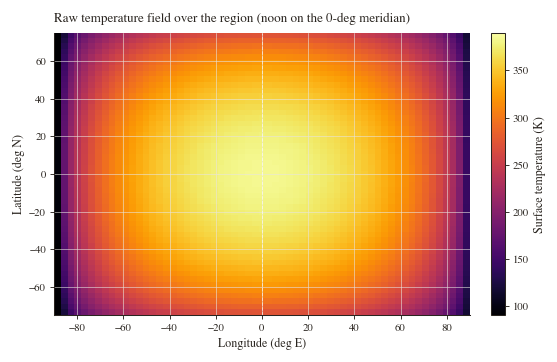

In [5]:
ext = [lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()]
fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
pc = ax.imshow(Tmap, extent=ext, origin='lower', aspect='auto',
               cmap='inferno', vmin=90, vmax=390)
fig.colorbar(pc, ax=ax).set_label('Surface temperature (K)')
ax.axvline(0, color='w', lw=0.8, ls='--', alpha=0.6)
fmt_axis(ax, xlabel='Longitude (deg E)', ylabel='Latitude (deg N)',
         title='Raw temperature field over the region (noon on the 0-deg meridian)')
plt.show()

## 4 — Drape it on the real surface (shape)

The smooth field says *what* the temperature is, but not *where*. We give it a
sense of place by draping it on the real lunar surface — the Clementine albedo
mosaic combined with **LOLA shaded relief**, so craters and maria show through
(temperature colour × relief shading). Nothing is re-solved.

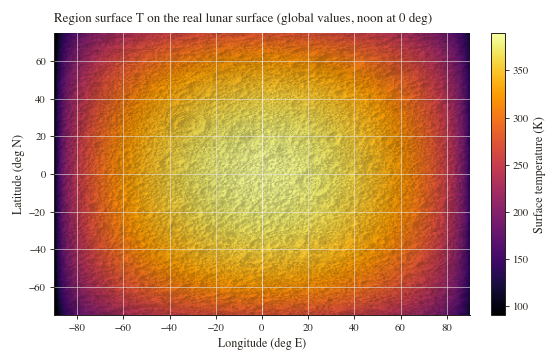

In [6]:
# --- real-surface basemap: Clementine albedo x LOLA hillshade -------------
ALB = CODE.parent / 'figures' / 'moon_global.png'
DEM = CODE.parent / 'aogs' / 'data' / 'lola' / 'ldem_16.img'

def _load_relief():
    alb = imread(str(ALB)); alb = alb[..., :3].mean(-1) if alb.ndim == 3 else alb
    Hn, Wn = alb.shape
    if DEM.exists():
        dem = np.fromfile(DEM, dtype='<i2').reshape(2880, 5760).astype(float) * 0.5
        fy, fx = 2880 // Hn, 5760 // Wn
        dem = dem[:fy*Hn:fy, :fx*Wn:fx][:Hn, :Wn]
        hs = LightSource(azdeg=300, altdeg=42).hillshade(dem, vert_exag=90, dx=1, dy=1)
    else:
        hs = np.full_like(alb, 0.6)
    base = 0.45 * (alb / max(alb.max(), 1e-6)) + 0.55 * hs
    return np.clip(0.35 + 0.75 * (base - base.min()) / (np.ptp(base) + 1e-9), 0, 1)

RELIEF = _load_relief(); Hn, Wn = RELIEF.shape

def relief_at(lat, lon):
    r = np.clip(((90 - lat) / 180 * (Hn - 1)).astype(int), 0, Hn - 1)
    c = np.clip(((lon + 180) / 360 * (Wn - 1)).astype(int), 0, Wn - 1)
    return RELIEF[r, c]

def drape(T2d, lat2d, lon2d):
    '''temperature colour x relief shading -> RGB (craters show through).'''
    col = cm.inferno((np.clip(T2d, 90, 390) - 90) / 300)[..., :3]
    shade = 0.42 + 0.58 * relief_at(lat2d, lon2d)
    return np.clip(col * shade[..., None], 0, 1)

# fine render grid (smooth temperature x fine relief -> visible craters)
FLA, FLO = np.meshgrid(np.linspace(lat_grid.min(), lat_grid.max(), 300),
                       np.linspace(lon_grid.min(), lon_grid.max(), 460), indexing='ij')
def region_rgb(sslon=0.0):
    return drape(T_at(FLA, FLO - sslon), FLA, FLO)

sm = cm.ScalarMappable(norm=Normalize(90, 390), cmap='inferno')
fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
ax.imshow(region_rgb(0.0), extent=ext, origin='lower', aspect='auto', interpolation='bilinear')
ax.axvline(0, color='w', lw=0.8, ls='--', alpha=0.6)
fig.colorbar(sm, ax=ax).set_label('Surface temperature (K)')
fmt_axis(ax, xlabel='Longitude (deg E)', ylabel='Latitude (deg N)',
         title='Region surface T on the real lunar surface (global values, noon at 0 deg)')
plt.show()

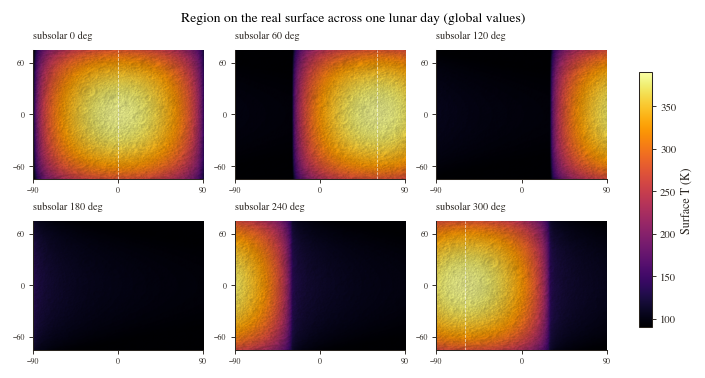

wrote figures/anim/lunar_region_daycycle.gif  (2.5 MB)


In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
ANIM = CODE.parent / 'figures' / 'anim'; ANIM.mkdir(parents=True, exist_ok=True)

figF, axes = plt.subplots(2, 3, figsize=(8.4, 4.4), constrained_layout=True)
for ax, ss in zip(axes.ravel(), [0, 60, 120, 180, 240, 300]):
    ax.imshow(region_rgb(ss), extent=ext, origin='lower', aspect='auto', interpolation='bilinear')
    ax.axvline(((ss + 180) % 360) - 180, color='w', lw=0.7, ls='--', alpha=0.7)
    ax.set_title(f'subsolar {ss:.0f} deg', fontsize=9)
    ax.set_xticks([-90, 0, 90]); ax.set_yticks([-60, 0, 60])
    ax.tick_params(labelsize=7); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
figF.colorbar(sm, ax=axes, shrink=0.85, label='Surface T (K)')
figF.suptitle('Region on the real surface across one lunar day (global values)')
plt.show()

figA, axA = plt.subplots(figsize=(5.2, 3.5))
imA = axA.imshow(region_rgb(0.0), extent=ext, origin='lower', aspect='auto', interpolation='bilinear')
ln = axA.axvline(0, color='w', lw=0.9, ls='--', alpha=0.7)
figA.colorbar(sm, ax=axA).set_label('Surface T (K)')
axA.set_xlabel('Longitude (deg E)'); axA.set_ylabel('Latitude (deg N)')
axA.set_xlim(ext[0], ext[1]); axA.set_ylim(ext[2], ext[3])
tt = axA.set_title(''); figA.tight_layout()
NF = 60
def _upd(f):
    ss = 360 * f / NF
    imA.set_data(region_rgb(ss))
    ln.set_xdata([((ss + 180) % 360) - 180] * 2)
    tt.set_text(f'Region surface T on the real surface -- subsolar {ss:.0f} deg')
    return [imA]
gif = ANIM / 'lunar_region_daycycle.gif'
FuncAnimation(figA, _upd, frames=NF, interval=70, blit=False).save(
    str(gif), writer=PillowWriter(fps=14), dpi=90)
plt.close(figA)
try:
    from PIL import Image, ImageSequence
    im = Image.open(gif)
    fr = [f.convert('RGB').quantize(colors=96) for f in ImageSequence.Iterator(im)]
    fr[0].save(gif, save_all=True, append_images=fr[1:], loop=0, duration=70, optimize=True)
except Exception as e:
    print('optimize skipped:', e)
print(f'wrote {gif.relative_to(CODE.parent)}  ({gif.stat().st_size/1e6:.1f} MB)')

The animation is saved to `figures/anim/lunar_region_daycycle.gif` and plays in
Jupyter — now on the real surface, the dashed line is local noon sweeping the region:

![Region surface temperature on the real surface across one lunar day](../../figures/anim/lunar_region_daycycle.gif)

## 5 — The polar regions

The equatorial band above never gets cold at noon. The **poles** are the
opposite story: with the Sun always near the horizon (grazing incidence), they
stay cold through the whole lunar day. We solve a ladder of high latitudes and
project each pole to a top-down disk (azimuthal-equidistant), draped on the
same LOLA relief.

North cap: coldest 59 K at the pole, warmest 333 K at the sunlit rim
South cap: coldest 59 K at the pole, warmest 333 K at the sunlit rim


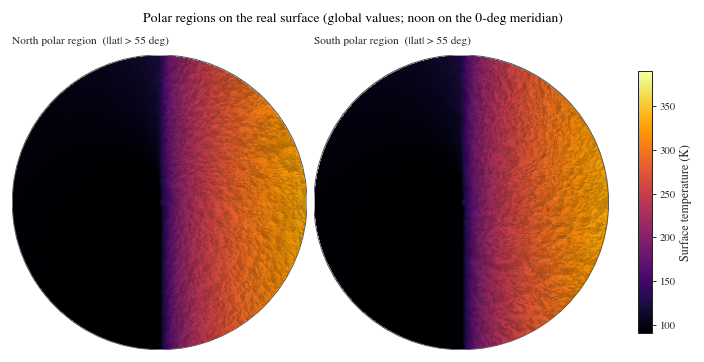

In [8]:
# extend the latitude ladder to the pole; T_at picks up the new FIELD
for la in [60., 65., 70., 75., 80., 85., 89.]:
    field.setdefault(la, one_solve(la))
ladder = np.array(sorted(field)); FIELD = np.array([field[la] for la in ladder])

def polar_rgba(pole, sslon=0.0, npx=300, lat_min=55.0):
    lin = np.linspace(-1, 1, npx); X, Y = np.meshgrid(lin, lin)
    r = np.hypot(X, Y); mask = r <= 1
    colat = r * (90 - lat_min)
    lat = (90 - colat) if pole == 'N' else -(90 - colat)
    lon = np.degrees(np.arctan2(Y, X))
    T = T_at(lat, lon - sslon)
    rgba = np.dstack([drape(T, lat, lon), mask.astype(float)])
    return rgba, np.where(mask, T, np.nan)

figP, (axN, axS) = plt.subplots(1, 2, figsize=(8.4, 4.4), constrained_layout=True)
for axp, pole, nm in [(axN, 'N', 'North'), (axS, 'S', 'South')]:
    rgba, T = polar_rgba(pole, sslon=0.0)
    axp.imshow(rgba, extent=[-1, 1, -1, 1], origin='lower', interpolation='bilinear')
    axp.add_patch(plt.Circle((0, 0), 1, fill=False, ec='0.35', lw=0.9))
    axp.set_aspect('equal'); axp.axis('off')
    axp.set_title(f'{nm} polar region  (|lat| > 55 deg)', fontsize=10)
    print(f'{nm} cap: coldest {np.nanmin(T):.0f} K at the pole, '
          f'warmest {np.nanmax(T):.0f} K at the sunlit rim')
figP.colorbar(sm, ax=[axN, axS], shrink=0.8, label='Surface temperature (K)')
figP.suptitle('Polar regions on the real surface (global values; noon on the 0-deg meridian)')
plt.show()

## Takeaways

- **The solver is the bottleneck of any map.** A map is *N* independent solves,
  so the per-pixel cost decides feasibility. Pure Python would take **~20 days**
  for a full-Moon map; the Numba solver (production) and the C++ port both do it
  in **hours**, and they agree to ~$10^{-12}$ K (notebook 07). That is why the
  science runs on Numba and C++ stays a cross-check.
- **Global values → a 1-D problem.** Uniform properties make the map
  latitude-banded, so the real cost collapses from *N* pixels to a handful of
  unique latitudes. The moment you make properties **per-pixel** (local albedo,
  slope, or a retrieved per-site $K_d$), that symmetry breaks and you are back
  to the full *N*-solve cost — which is exactly when the fast solver earns its
  keep.
- **Geography matters at the poles.** Draped on the real surface you can read
  the map as a place; and the poles — with the Sun forever near the horizon —
  stay cold through the entire lunar day, the regime that makes lunar cold
  traps possible.

## 📎 Code this notebook uses
*(full map of every notebook → [`README.md`](README.md))*

- **Engine — `src/lunar/`:** `config`, `constants`, `grid`, `solver`, `plotting`
- **Data — `results/`:** `cpp_benchmark.json` (real Python / Numba / C++ timings)
- **Surface texture:** `figures/moon_global.png` (Clementine albedo, USGS/NASA),
  `aogs/data/lola/ldem_16.img` (LOLA relief)

> A scale-up demo: what does it take to simulate a **big region of the Moon**?
> We use **global values** (one Hayne conductivity, one albedo, one basal flux
> everywhere — no per-site retrieval) and compare the *process* of mapping it,
> then drape the result on the real lunar surface and add the poles.